In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
 
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    mean_absolute_error, r2_score
)


plt.style.use("seaborn-v0_8-whitegrid")
 
C = {
    "coral":  "#D85A30", "teal":   "#1D9E75",
    "green":  "#639922", "amber":  "#BA7517",
    "red":    "#E24B4A", "gray":   "#888780",
    "blue":   "#378ADD", "purple": "#7F77DD",
    "pink":   "#D4537E",
}
MODEL_COLORS = {
    "Logistic Regression": C["blue"],
    "Decision Tree":       C["amber"],
    "Random Forest":       C["teal"],
    "Gradient Boosting":   C["coral"],
    "Ridge Regression":    C["blue"]
}

In [2]:

df_tele  = pd.read_csv("eco_driving_score.csv")
df_under = pd.read_csv("car_insurance.csv")


In [3]:
tele_corr = df_tele.corr()["eco_score"].drop("eco_score").sort_values()
print("\n  Correlations with eco_score:")
for feat, corr in tele_corr.items():
    direction = "negative" if corr < 0 else "positive"
    print(f"    {feat:<30} {corr:>7.4f}  ({direction})")



  Correlations with eco_score:
    fuel_consumption               -0.7706  (negative)
    harsh_braking_count            -0.7425  (negative)
    rpm_variation                  -0.5375  (negative)
    idling_time                    -0.4680  (negative)
    acceleration_smoothness         0.4810  (positive)


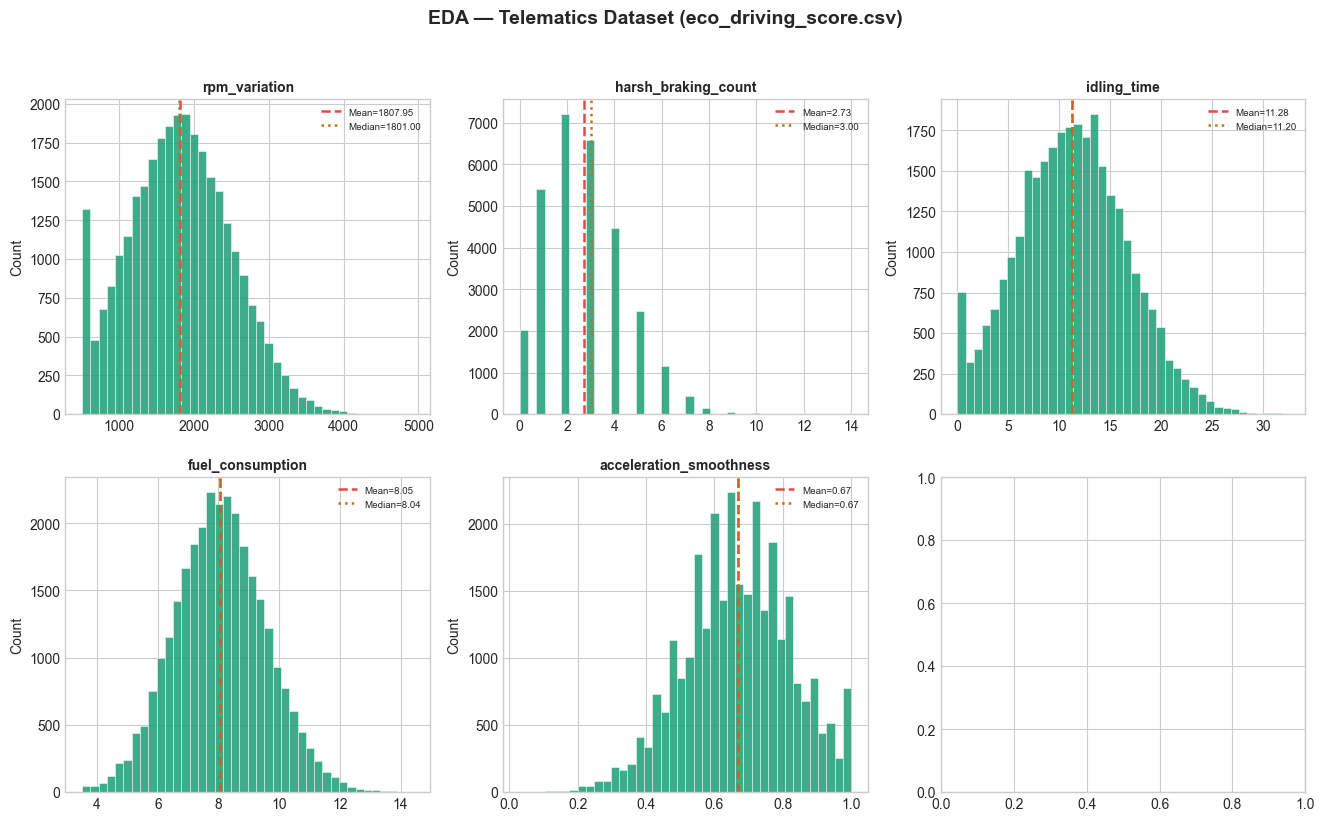

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Telematics Dataset (eco_driving_score.csv)",
             fontsize=14, fontweight="bold")
 
tele_feature_cols = ["rpm_variation", "harsh_braking_count", "idling_time",
                     "fuel_consumption", "acceleration_smoothness"]
 
for idx, col in enumerate(tele_feature_cols):
    ax = axes[idx // 3][idx % 3]
    ax.hist(df_tele[col], bins=40, color=C["teal"], alpha=0.85,
            edgecolor="white", linewidth=0.4)
    mean_val = df_tele[col].mean()
    median_val = df_tele[col].median()
    ax.axvline(mean_val,   color=C["red"],   lw=1.8, ls="--", label=f"Mean={mean_val:.2f}")
    ax.axvline(median_val, color=C["amber"], lw=1.8, ls=":",  label=f"Median={median_val:.2f}")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)


In [4]:
print("\n Building Gate 1 — underwriting eligibility model ...\n")
 
CAT_FEATURES_G1 = [
    "driving_experience", "education", "income",
    "vehicle_year", "vehicle_type"
]
NUM_FEATURES_G1 = [
    "age", "gender", "credit_score", "vehicle_ownership",
    "married", "children", "annual_mileage",
    "speeding_violations", "duis", "past_accidents"
]
 
print(f"  Outcome distribution:")
print(f"    No claim (0): {(df_under['outcome']==0).sum():,}  ({(df_under['outcome']==0).mean():.1%})")
print(f"    Claim    (1): {(df_under['outcome']==1).sum():,}  ({(df_under['outcome']==1).mean():.1%})")
print(f"  Missing values: credit_score={df_under['credit_score'].isnull().sum()}, "
      f"annual_mileage={df_under['annual_mileage'].isnull().sum()} -> median imputed")
 
X1 = df_under[CAT_FEATURES_G1 + NUM_FEATURES_G1].copy()
y1 = df_under["outcome"].astype(int)



 Building Gate 1 — underwriting eligibility model ...

  Outcome distribution:
    No claim (0): 6,867  (68.7%)
    Claim    (1): 3,133  (31.3%)
  Missing values: credit_score=982, annual_mileage=957 -> median imputed


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("EDA — Claim Rate by Categorical Feature",
             fontsize=13, fontweight="bold")
 
for idx, col in enumerate(CAT_FEATURES_G1):
    ax = axes[idx]
    rates  = df_under.groupby(col)["outcome"].mean().sort_values(ascending=False)
    counts = df_under[col].value_counts()
    bar_colors = [C["red"] if r > 0.4 else C["amber"] if r > 0.2 else C["teal"]
                  for r in rates.values]
    bars = ax.bar(range(len(rates)), rates.values,
                  color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Claim Rate")
    ax.set_title(col.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.set_ylim(0, 0.8)
    ax.axhline(df_under["outcome"].mean(), color="k",
               ls="--", lw=1.2, alpha=0.5, label=f"Overall mean={df_under['outcome'].mean():.2f}")
    ax.legend(fontsize=7)
    for bar, rate, cat in zip(bars, rates.values, rates.index):
        n = counts.get(cat, 0)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{rate:.0%}\n(n={n:,})", ha="center", va="bottom", fontsize=7)
 
plt.tight_layout()
plt.savefig("eda5_underwriting_claim_rates.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: eda5_underwriting_claim_rates.png")

  Saved: eda5_underwriting_claim_rates.png


In [6]:
TELE_FEATURES   = ["rpm_variation", "harsh_braking_count", "idling_time",
                    "fuel_consumption", "acceleration_smoothness"]

num_transformer = Pipeline([("impute", SimpleImputer(strategy="median"))])
cat_transformer = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
 
preprocessor_g1 = ColumnTransformer([
    ("num", num_transformer, NUM_FEATURES_G1),
    ("cat", cat_transformer, CAT_FEATURES_G1),
])
 
X1 = df_under[CAT_FEATURES_G1 + NUM_FEATURES_G1].copy()
y1 = df_under["outcome"].astype(int)
 
X2 = df_tele[TELE_FEATURES]
y2 = df_tele["eco_score"]
 
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)
 
print(f"  Gate 1 — train: {len(X1_train):,}  test: {len(X1_test):,}")
print(f"  Gate 2 — train: {len(X2_train):,}  test: {len(X2_test):,}")
print(f"  Gate 1 missing values: credit_score={df_under['credit_score'].isnull().sum()}, "
      f"annual_mileage={df_under['annual_mileage'].isnull().sum()} → median imputed")
print(f"  Gate 2 missing values: none")

  Gate 1 — train: 8,000  test: 2,000
  Gate 2 — train: 24,000  test: 6,000
  Gate 1 missing values: credit_score=982, annual_mileage=957 → median imputed
  Gate 2 missing values: none


In [7]:
print("\n[Gate 1 — comparing classifiers ...\n")
 
gate1_candidates = {
    "Logistic Regression": Pipeline([
        ("prep",  preprocessor_g1),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Decision Tree": Pipeline([
        ("prep",  preprocessor_g1),
        ("model", DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                          random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("prep",  preprocessor_g1),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=8,
                                          min_samples_leaf=10, n_jobs=-1,
                                          random_state=42)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep",  preprocessor_g1),
        ("model", GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                              learning_rate=0.08, subsample=0.8,
                                              min_samples_leaf=20, random_state=42)),
    ]),
}
 
cv_g1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
g1_results  = []
g1_roc_data = {}
g1_best_name, g1_best_auc, g1_best_model = None, 0, None
 
print(f"  {'Model':<22} {'CV AUC':>8} {'CV Std':>8} {'Test AUC':>9} {'Time(s)':>8}")
print("  " + "-" * 60)
 
for name, pipeline in gate1_candidates.items():
    t0 = time.time()
    cv_scores = cross_val_score(pipeline, X1, y1, cv=cv_g1,
                                scoring="roc_auc", n_jobs=-1)
    pipeline.fit(X1_train, y1_train)
    y_proba  = pipeline.predict_proba(X1_test)[:, 1]
    y_pred   = pipeline.predict(X1_test)
    test_auc = roc_auc_score(y1_test, y_proba)
    elapsed  = time.time() - t0
 
    fpr, tpr, _ = roc_curve(y1_test, y_proba)
    g1_roc_data[name] = (fpr, tpr, test_auc)
 
    g1_results.append({
        "model":    name,
        "cv_auc":   cv_scores.mean(),
        "cv_std":   cv_scores.std(),
        "test_auc": test_auc,
        "time":     elapsed,
        "pipeline": pipeline,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
    })
 
    marker = " <<< best" if test_auc > g1_best_auc else ""
    print(f"  {name:<22} {cv_scores.mean():>8.4f} {cv_scores.std():>8.4f} "
          f"{test_auc:>9.4f} {elapsed:>8.1f}{marker}")
 
    if test_auc > g1_best_auc:
        g1_best_auc, g1_best_name, g1_best_model = test_auc, name, pipeline
 
 
best_g1_result = next(r for r in g1_results if r["model"] == g1_best_name)
y1_pred_final  = best_g1_result["y_pred"]
y1_proba_final = best_g1_result["y_proba"]
 
print(f"\n  Classification report — {g1_best_name}:")
print(classification_report(y1_test, y1_pred_final,
      target_names=["No claim (eligible)", "Claim (high risk)"]))
 


[Gate 1 — comparing classifiers ...

  Model                    CV AUC   CV Std  Test AUC  Time(s)
  ------------------------------------------------------------
  Logistic Regression      0.8982   0.0027    0.8853     14.6 <<< best
  Decision Tree            0.8873   0.0015    0.8733      9.0
  Random Forest            0.8944   0.0029    0.8769     12.4
  Gradient Boosting        0.8951   0.0044    0.8797     10.8

  Classification report — Logistic Regression:
                     precision    recall  f1-score   support

No claim (eligible)       0.87      0.88      0.88      1373
  Claim (high risk)       0.73      0.71      0.72       627

           accuracy                           0.83      2000
          macro avg       0.80      0.80      0.80      2000
       weighted avg       0.83      0.83      0.83      2000



In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Gate 1 — Classifier Comparison (Underwriting Eligibility)",
             fontsize=13, fontweight="bold")

names_g1  = [r["model"] for r in g1_results]
cv_aucs   = [r["cv_auc"] for r in g1_results]
cv_stds   = [r["cv_std"] for r in g1_results]
colors_g1 = [MODEL_COLORS.get(n, C["gray"]) for n in names_g1]
 
bars = axes[0].barh(names_g1, cv_aucs, xerr=cv_stds, color=colors_g1,
                    alpha=0.85, edgecolor="white", capsize=4)
axes[0].axvline(0.5, color="k", ls="--", lw=1, alpha=0.4)
for bar, val in zip(bars, cv_aucs):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)
axes[0].set_xlabel("CV AUC (5-fold ± std)")
axes[0].set_title("Cross-Validation AUC")
axes[0].set_xlim(0.5, 1.0)
winner_idx = names_g1.index(g1_best_name)
bars[winner_idx].set_edgecolor("black")
bars[winner_idx].set_linewidth(2.5)
 

for name, (fpr, tpr, auc) in g1_roc_data.items():
    lw = 2.5 if name == g1_best_name else 1.2
    ls = "-"  if name == g1_best_name else "--"
    axes[1].plot(fpr, tpr, lw=lw, ls=ls,
                 color=MODEL_COLORS.get(name, C["gray"]),
                 label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"k:", lw=1, alpha=0.4)
axes[1].fill_between(*g1_roc_data[g1_best_name][:2], alpha=0.08,
                     color=MODEL_COLORS.get(g1_best_name, C["gray"]))
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — All Models")
axes[1].legend(fontsize=8, loc="lower right")
 

cm = confusion_matrix(y1_test, y1_pred_final)
axes[2].imshow(cm, cmap="Oranges")
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(["No Claim", "Claim"])
axes[2].set_yticklabels(["No Claim", "Claim"])
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
axes[2].set_title(f"Confusion Matrix\n{g1_best_name} (winner)")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                     fontsize=13, fontweight="bold",
                     color="white" if cm[i,j] > cm.max()/2 else "black")
 
plt.tight_layout()
plt.savefig("gate1_model_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n  Saved: gate1_model_comparison.png")


  Saved: gate1_model_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle(f"Gate 1 — Feature Importances ({g1_best_name})",
             fontsize=13, fontweight="bold")
 
ohe_names = (g1_best_model.named_steps["prep"]
             .named_transformers_["cat"]
             .named_steps["ohe"]
             .get_feature_names_out(CAT_FEATURES_G1).tolist())
feat_names_g1 = NUM_FEATURES_G1 + ohe_names
 
if hasattr(g1_best_model.named_steps["model"], "feature_importances_"):
    importances = g1_best_model.named_steps["model"].feature_importances_
    xlabel = "Feature Importance"
else:
    importances = np.abs(g1_best_model.named_steps["model"].coef_[0])
    xlabel = "|Coefficient|"
 
top_idx = np.argsort(importances)[-15:]
bar_colors_fi = [C["coral"] if importances[i] > np.median(importances) else C["amber"]
                 for i in top_idx]
ax.barh([feat_names_g1[i] for i in top_idx], importances[top_idx],
        color=bar_colors_fi, alpha=0.85, edgecolor="white")
ax.set_xlabel(xlabel)
ax.set_title(f"Top 15 Features")
ax.tick_params(labelsize=9)
 
plt.tight_layout()
plt.savefig("gate1_feature_importance.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: gate1_feature_importance.png")
 

  Saved: gate1_feature_importance.png


In [10]:
print("\n[Step 6] Gate 2 — comparing regressors ...\n")
 
gate2_candidates = {
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=6, min_samples_leaf=20,
                                               random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=8,
                                               min_samples_leaf=10, n_jobs=-1,
                                               random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.08, subsample=0.8,
                                                    min_samples_leaf=20, random_state=42),
}
 
cv_g2 = KFold(n_splits=5, shuffle=True, random_state=42)
g2_results  = []
g2_pred_map = {}
g2_best_name, g2_best_r2, g2_best_model = None, -np.inf, None
 
print(f"  {'Model':<22} {'CV R2':>8} {'CV Std':>8} {'Test R2':>8} {'MAE':>8} {'Time(s)':>8}")
print("  " + "-" * 68)
 
for name, model in gate2_candidates.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X2, y2, cv=cv_g2, scoring="r2", n_jobs=-1)
    model.fit(X2_train, y2_train)
    y_pred   = model.predict(X2_test)
    test_r2  = r2_score(y2_test, y_pred)
    test_mae = mean_absolute_error(y2_test, y_pred)
    elapsed  = time.time() - t0
 
    g2_pred_map[name] = y_pred
    g2_results.append({
        "model":   name,
        "cv_r2":   cv_scores.mean(),
        "cv_std":  cv_scores.std(),
        "test_r2": test_r2,
        "mae":     test_mae,
        "time":    elapsed,
        "fitted":  model,
    })
 
    marker = " <<< best" if test_r2 > g2_best_r2 else ""
    print(f"  {name:<22} {cv_scores.mean():>8.4f} {cv_scores.std():>8.4f} "
          f"{test_r2:>8.4f} {test_mae:>8.2f} {elapsed:>8.1f}{marker}")
 
    if test_r2 > g2_best_r2:
        g2_best_r2, g2_best_name, g2_best_model = test_r2, name, model
 
g2_best_mae = next(r["mae"] for r in g2_results if r["model"] == g2_best_name)
 


[Step 6] Gate 2 — comparing regressors ...

  Model                     CV R2   CV Std  Test R2      MAE  Time(s)
  --------------------------------------------------------------------
  Ridge Regression         0.9317   0.0012   0.9317     4.00      0.2 <<< best
  Decision Tree            0.8159   0.0043   0.8097     6.63      0.2
  Random Forest            0.9025   0.0029   0.8982     4.86     12.3
  Gradient Boosting        0.9316   0.0016   0.9296     4.05     18.7


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Gate 2 — Regressor Comparison (Eco-Driving Score)",
             fontsize=13, fontweight="bold")
 

names_g2  = [r["model"] for r in g2_results]
cv_r2s    = [r["cv_r2"] for r in g2_results]
cv_stds2  = [r["cv_std"] for r in g2_results]
maes      = [r["mae"]    for r in g2_results]
colors_g2 = [MODEL_COLORS.get(n, C["gray"]) for n in names_g2]
 
bars2 = axes[0].barh(names_g2, cv_r2s, xerr=cv_stds2, color=colors_g2,
                     alpha=0.85, edgecolor="white", capsize=4)
for bar, val in zip(bars2, cv_r2s):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)
axes[0].set_xlabel("CV R² (5-fold ± std)")
axes[0].set_title("Cross-Validation R²")
axes[0].set_xlim(0, 1.05)
winner_idx2 = names_g2.index(g2_best_name)
bars2[winner_idx2].set_edgecolor("black")
bars2[winner_idx2].set_linewidth(2.5)
 

sample_idx = np.random.RandomState(42).choice(len(y2_test), 1000, replace=False)
y_actual_s  = y2_test.iloc[sample_idx].values
for name, preds in g2_pred_map.items():
    alpha = 0.45 if name == g2_best_name else 0.12
    size  = 10   if name == g2_best_name else 4
    axes[1].scatter(y_actual_s, preds[sample_idx], alpha=alpha, s=size,
                    color=MODEL_COLORS.get(name, C["gray"]), label=name)
mn = min(y2_test.min(), min(p.min() for p in g2_pred_map.values()))
mx = max(y2_test.max(), max(p.max() for p in g2_pred_map.values()))
axes[1].plot([mn,mx],[mn,mx],"k--", lw=1.5, label="Perfect fit")
axes[1].set_xlabel("Actual eco_score")
axes[1].set_ylabel("Predicted eco_score")
axes[1].set_title("Predicted vs Actual — All Models")
axes[1].legend(fontsize=7, markerscale=2)
 

bars3 = axes[2].barh(names_g2, maes, color=colors_g2, alpha=0.85, edgecolor="white")
for bar, val in zip(bars3, maes):
    axes[2].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=9)
axes[2].set_xlabel("MAE (eco score points — lower is better)")
axes[2].set_title("Mean Absolute Error")
bars3[winner_idx2].set_edgecolor("black")
bars3[winner_idx2].set_linewidth(2.5)
 
plt.tight_layout()
plt.savefig("gate2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n  Saved: gate2_model_comparison.png")


  Saved: gate2_model_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"Gate 2 — {g2_best_name} Diagnostics",
             fontsize=13, fontweight="bold")
 
best_preds = g2_pred_map[g2_best_name]
residuals  = y2_test.values - best_preds
 

axes[0].hist(residuals, bins=50, color=C["teal"], alpha=0.85, edgecolor="white", lw=0.3)
axes[0].axvline(0, color="k", lw=2, ls="--")
axes[0].axvline(residuals.mean(),   color=C["red"],   lw=1.5, ls="--",
                label=f"Mean={residuals.mean():.2f}")
axes[0].axvline(residuals.std(),    color=C["amber"], lw=1.5, ls=":",
                label=f"Std={residuals.std():.2f}")
axes[0].set_xlabel("Residual (actual − predicted)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Residual Distribution  (MAE={g2_best_mae:.2f})")
axes[0].legend(fontsize=8)
 

axes[1].scatter(best_preds, residuals, alpha=0.15, s=5, color=C["teal"])
axes[1].axhline(0, color="k", lw=1.5, ls="--")
axes[1].set_xlabel("Predicted eco_score")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted\n(check for heteroscedasticity)")
 

if hasattr(g2_best_model, "feature_importances_"):
    importances2 = g2_best_model.feature_importances_
    xlabel2 = "Feature Importance"
else:
    importances2 = np.abs(g2_best_model.coef_)
    xlabel2 = "|Coefficient|"
 
sorted_idx = np.argsort(importances2)
axes[2].barh([TELE_FEATURES[i] for i in sorted_idx], importances2[sorted_idx],
             color=C["teal"], alpha=0.85, edgecolor="white")
for i, (feat_i, val) in enumerate(zip(sorted_idx, importances2[sorted_idx])):
    axes[2].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=9)
axes[2].set_xlabel(xlabel2)
axes[2].set_title(f"Feature Importances\n{g2_best_name}")
 
plt.tight_layout()
plt.savefig("gate2_diagnostics.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: gate2_diagnostics.png")
 

  Saved: gate2_diagnostics.png


In [13]:
print("\n[Step 7] Running combined decision pipeline ...\n")
 
gate1 = g1_best_model
gate2 = g2_best_model
 

p33 = float(np.percentile(y2, 33))
p66 = float(np.percentile(y2, 66))
 
def score_to_label(score):
    if   score >= p66: return "A"
    elif score >= p33: return "B"
    else:              return "C"
 
RISK_THRESHOLD   = 0.5
BASE_PREMIUM     = 1000
DISCOUNT_MAP     = {"A": 0.15, "B": 0.00, "C": 0.00}
PREMIUM_LOAD_MAP = {"A": 0.00, "B": 0.00, "C": 0.05}
 
print(f"  Green label thresholds:")
print(f"    A  eco_score >= {p66:.1f}  → approve + 15% discount")
print(f"    B  eco_score >= {p33:.1f}  → approve, standard premium")
print(f"    C  eco_score <  {p33:.1f}  → approve + 5% loading")
print(f"    Gate 1 risk threshold: {RISK_THRESHOLD}")
 
 
def make_decision(under_row: dict, tele_row: dict) -> dict:
    """
    Sequential two-gate decision.
    Gate 1 runs first — if rejected, Gate 2 is never evaluated.
    """
    u_df = pd.DataFrame([under_row])[CAT_FEATURES_G1 + NUM_FEATURES_G1]
    risk_prob = float(gate1.predict_proba(u_df)[0][1])
 
    if risk_prob >= RISK_THRESHOLD:
        return {
            "gate1_risk_prob":     round(risk_prob, 4),
            "gate1_pass":          False,
            "decision":            "REJECT",
            "green_label":         None,
            "eco_score":           None,
            "discount_pct":        0,
            "premium_loading_pct": 0,
            "final_premium":       None,
        }
 
    t_df    = pd.DataFrame([tele_row])[TELE_FEATURES]
    eco     = float(gate2.predict(t_df)[0])
    label   = score_to_label(eco)
    premium = round(BASE_PREMIUM * (1 - DISCOUNT_MAP[label]) *
                    (1 + PREMIUM_LOAD_MAP[label]), 2)
 
    return {
        "gate1_risk_prob":     round(risk_prob, 4),
        "gate1_pass":          True,
        "decision":            "APPROVE",
        "green_label":         label,
        "eco_score":           round(eco, 1),
        "discount_pct":        DISCOUNT_MAP[label] * 100,
        "premium_loading_pct": PREMIUM_LOAD_MAP[label] * 100,
        "final_premium":       premium,
    }
 
 
# Run pipeline on all applicants (aligned by row index)
N_eval  = min(len(df_under), len(df_tele))
results = []
for i in range(N_eval):
    ur = df_under[CAT_FEATURES_G1 + NUM_FEATURES_G1].iloc[i].to_dict()
    tr = df_tele[TELE_FEATURES].iloc[i].to_dict()
    results.append(make_decision(ur, tr))
 
results_df = pd.DataFrame(results)
approved   = results_df[results_df["decision"] == "APPROVE"]
rejected   = results_df[results_df["decision"] == "REJECT"]
 

print(f"\n  Sample decisions (first 8 applicants):\n")
print(f"  {'#':<4} {'Risk Prob':>10} {'Pass':>5} {'Label':>6} "
      f"{'EcoScore':>9} {'Discount':>9} {'Loading':>8} {'Premium':>9}  Decision")
print("  " + "-" * 78)
for i in range(min(8, len(results_df))):
    r = results_df.iloc[i]
    print(f"  {i+1:<4} {r['gate1_risk_prob']:>10.3f} {str(r['gate1_pass']):>5} "
          f"{str(r['green_label']):>6} {str(r['eco_score']):>9} "
          f"{r['discount_pct']:>8.0f}% {r['premium_loading_pct']:>7.0f}% "
          f"{str(r['final_premium']):>9}  {r['decision']}")
 
print(f"\n  Pipeline summary ({N_eval:,} applicants):")
print(f"    Approved : {len(approved):,}  ({len(approved)/N_eval:.1%})")
print(f"    Rejected : {len(rejected):,}  ({len(rejected)/N_eval:.1%})")
for lbl in ["A", "B", "C"]:
    n     = (approved["green_label"] == lbl).sum()
    avg_p = approved[approved["green_label"] == lbl]["final_premium"].mean()
    print(f"    Label {lbl}  : {n:,} ({n/len(approved):.1%})  "
          f"avg premium Rs{avg_p:.0f}  "
          f"discount {DISCOUNT_MAP[lbl]*100:.0f}%  "
          f"loading {PREMIUM_LOAD_MAP[lbl]*100:.0f}%")


[Step 7] Running combined decision pipeline ...

  Green label thresholds:
    A  eco_score >= 56.5  → approve + 15% discount
    B  eco_score >= 39.3  → approve, standard premium
    C  eco_score <  39.3  → approve + 5% loading
    Gate 1 risk threshold: 0.5

  Sample decisions (first 8 applicants):

  #     Risk Prob  Pass  Label  EcoScore  Discount  Loading   Premium  Decision
  ------------------------------------------------------------------------------
  1         0.141  True      B      44.8        0%       0%    1000.0  APPROVE
  2         0.953 False   None       nan        0%       0%       nan  REJECT
  3         0.558 False   None       nan        0%       0%       nan  REJECT
  4         0.731 False   None       nan        0%       0%       nan  REJECT
  5         0.345  True      A      74.4       15%       0%     850.0  APPROVE
  6         0.004  True      B      42.9        0%       0%    1000.0  APPROVE
  7         0.035  True      C      27.5        0%       5%    1

In [14]:
lbl_color_map = {"A": C["green"], "B": C["teal"], "C": C["amber"]}
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Combined Pipeline — Decision Outcomes", fontsize=14, fontweight="bold")
 
# Gate 1 pass/fail pie
axes[0][0].pie(
    [len(approved), len(rejected)],
    labels=[f"Approved\n{len(approved):,} ({len(approved)/N_eval:.1%})",
            f"Rejected\n{len(rejected):,} ({len(rejected)/N_eval:.1%})"],
    colors=[C["teal"], C["red"]], autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 10}, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0][0].set_title("Gate 1 — Pass / Fail Split", fontsize=11, fontweight="bold")
 
# Green label distribution (approved only)
lbl_counts = approved["green_label"].value_counts().sort_index()
bar_cols   = [lbl_color_map.get(l, C["gray"]) for l in lbl_counts.index]
bars_lbl   = axes[0][1].bar(lbl_counts.index, lbl_counts.values,
                              color=bar_cols, alpha=0.85, edgecolor="white", width=0.5)
for bar, val in zip(bars_lbl, lbl_counts.values):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f"{val:,}\n({val/len(approved):.1%})",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0][1].set_xlabel("Green Label")
axes[0][1].set_ylabel("Number of Applicants")
axes[0][1].set_title("Gate 2 — Green Label Distribution\n(approved applicants only)",
                      fontsize=11, fontweight="bold")
# Gate 1 risk probability distribution
axes[0][2].hist(results_df[results_df["gate1_pass"]==True]["gate1_risk_prob"],
                bins=40, alpha=0.7, color=C["teal"],
                label="Approved", edgecolor="white", lw=0.3)
axes[0][2].hist(results_df[results_df["gate1_pass"]==False]["gate1_risk_prob"],
                bins=40, alpha=0.7, color=C["red"],
                label="Rejected", edgecolor="white", lw=0.3)
axes[0][2].axvline(RISK_THRESHOLD, color="k", lw=2, ls="--",
                   label=f"Threshold={RISK_THRESHOLD}")
axes[0][2].set_xlabel("Gate 1 Risk Probability")
axes[0][2].set_ylabel("Count")
axes[0][2].set_title("Risk Probability Distribution by Decision",
                      fontsize=11, fontweight="bold")
axes[0][2].legend(fontsize=9)
 
# Eco score distribution by label
for lbl, grp in approved.groupby("green_label"):
    axes[1][0].hist(grp["eco_score"], bins=30, alpha=0.65,
                    label=f"Label {lbl}  (n={len(grp):,})",
                    color=lbl_color_map.get(lbl, C["gray"]), edgecolor="white", lw=0.3)
axes[1][0].axvline(p33, color="k", ls="--", lw=1.5, alpha=0.6, label=f"p33 = {p33:.0f}")
axes[1][0].axvline(p66, color="k", ls="-",  lw=1.5, alpha=0.6, label=f"p66 = {p66:.0f}")
axes[1][0].set_xlabel("Predicted Eco Score")
axes[1][0].set_ylabel("Count")
axes[1][0].set_title("Eco Score Distribution by Green Label",
                      fontsize=11, fontweight="bold")
axes[1][0].legend(fontsize=8)
 
# Final premium distribution by label
for lbl, grp in approved.groupby("green_label"):
    axes[1][1].hist(grp["final_premium"], bins=15, alpha=0.65,
                    label=f"Label {lbl}", color=lbl_color_map.get(lbl, C["gray"]),
                    edgecolor="white", lw=0.3)
axes[1][1].set_xlabel("Final Premium (Rs)")
axes[1][1].set_ylabel("Count")
axes[1][1].set_title("Final Premium Distribution by Green Label",
                      fontsize=11, fontweight="bold")
axes[1][1].legend(fontsize=9)
 
# Premium summary bar chart
lbl_order = ["A", "B", "C"]
avg_premiums = [approved[approved["green_label"]==l]["final_premium"].mean()
                for l in lbl_order]
bar_p = axes[1][2].bar(lbl_order, avg_premiums,
                        color=[lbl_color_map[l] for l in lbl_order],
                        alpha=0.85, edgecolor="white", width=0.45)
for bar, val, lbl in zip(bar_p, avg_premiums, lbl_order):
    disc = DISCOUNT_MAP[lbl]*100
    load = PREMIUM_LOAD_MAP[lbl]*100
    axes[1][2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f"Rs{val:.0f}\n({'-' if disc>0 else '+'}{disc if disc>0 else load:.0f}%)",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1][2].set_xlabel("Green Label")
axes[1][2].set_ylabel("Average Premium (Rs)")
axes[1][2].set_ylim(0, BASE_PREMIUM * 1.3)
axes[1][2].axhline(BASE_PREMIUM, color="k", ls="--", lw=1.2,
                   alpha=0.5, label=f"Base = Rs{BASE_PREMIUM}")
axes[1][2].set_title("Average Premium by Green Label",
                      fontsize=11, fontweight="bold")
axes[1][2].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("pipeline_outcomes.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n  Saved: pipeline_outcomes.png")


  Saved: pipeline_outcomes.png


In [15]:
print("\n[Step 8] Complete\n")
print("=" * 65)

print("  MODEL SELECTION RESULTS")
print()
print("  Gate 1 — Classifiers (ranked by CV AUC):")
for r in sorted(g1_results, key=lambda x: x["cv_auc"], reverse=True):
    star = "  <<< SELECTED" if r["model"] == g1_best_name else ""
    print(f"    {r['model']:<22} CV AUC={r['cv_auc']:.4f} ±{r['cv_std']:.4f}  "
          f"Test AUC={r['test_auc']:.4f}{star}")
print()
print("  Gate 2 — Regressors (ranked by CV R²):")
for r in sorted(g2_results, key=lambda x: x["cv_r2"], reverse=True):
    star = "  <<< SELECTED" if r["model"] == g2_best_name else ""
    print(f"    {r['model']:<22} CV R²={r['cv_r2']:.4f} ±{r['cv_std']:.4f}  "
          f"MAE={r['mae']:.2f}{star}")
print()
print("  GATE PERFORMANCE OUTPUTS")
print("    gate1_model_comparison.png")
print("    gate1_feature_importance.png")
print("    gate2_model_comparison.png")
print("    gate2_diagnostics.png")
print()
print("  COMBINED PIPELINE RESULTS")
print(f"    Gate 1 winner : {g1_best_name}  (AUC={g1_best_auc:.4f})")
print(f"    Gate 2 winner : {g2_best_name}  (R²={g2_best_r2:.4f}, MAE={g2_best_mae:.2f})")
print(f"    Applicants    : {N_eval:,}")
print(f"    Approved      : {len(approved):,} ({len(approved)/N_eval:.1%})")
print(f"    Rejected      : {len(rejected):,} ({len(rejected)/N_eval:.1%})")
for lbl in ["A", "B", "C"]:
    n     = (approved["green_label"] == lbl).sum()
    avg_p = approved[approved["green_label"] == lbl]["final_premium"].mean()
    print(f"    Label {lbl}       : {n:,} ({n/len(approved):.1%})  avg premium £{avg_p:.0f}")
print()
print("  PIPELINE OUTPUT")
print("    pipeline_outcomes.png")
print("=" * 65)



[Step 8] Complete

  MODEL SELECTION RESULTS

  Gate 1 — Classifiers (ranked by CV AUC):
    Logistic Regression    CV AUC=0.8982 ±0.0027  Test AUC=0.8853  <<< SELECTED
    Gradient Boosting      CV AUC=0.8951 ±0.0044  Test AUC=0.8797
    Random Forest          CV AUC=0.8944 ±0.0029  Test AUC=0.8769
    Decision Tree          CV AUC=0.8873 ±0.0015  Test AUC=0.8733

  Gate 2 — Regressors (ranked by CV R²):
    Ridge Regression       CV R²=0.9317 ±0.0012  MAE=4.00  <<< SELECTED
    Gradient Boosting      CV R²=0.9316 ±0.0016  MAE=4.05
    Random Forest          CV R²=0.9025 ±0.0029  MAE=4.86
    Decision Tree          CV R²=0.8159 ±0.0043  MAE=6.63

  GATE PERFORMANCE OUTPUTS
    gate1_model_comparison.png
    gate1_feature_importance.png
    gate2_model_comparison.png
    gate2_diagnostics.png

  COMBINED PIPELINE RESULTS
    Gate 1 winner : Logistic Regression  (AUC=0.8853)
    Gate 2 winner : Ridge Regression  (R²=0.9317, MAE=4.00)
    Applicants    : 10,000
    Approved      : 7,032